In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'retail-sales-dataset' dataset.
Path to dataset files: /kaggle/input/retail-sales-dataset


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

#plot styling
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14
sns.set_theme(style='whitegrid',palette='Set2')
print('libraries loaded successfully')

libraries loaded successfully


## **Step 1: DATA LOADING AND CLEANING**

In [5]:
import matplotlib.ticker as mticker

In [6]:
df = pd.read_csv('/kaggle/input/retail-sales-dataset/retail_sales_dataset.csv',parse_dates=['Date'])
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
print('dataset shape:',df.shape)

dataset shape: (1000, 9)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [9]:
#missing values
missing = df.isnull().sum()
print('missing values per column:')
print(missing[missing>0]if missing.any() else 'No missing values')

missing values per column:
No missing values


In [10]:
#DUPLICATES VALUES
dupes=df.duplicated().sum()
print(f'Duplicate rows:{dupes}')
df.drop_duplicates(inplace=True)


Duplicate rows:0


In [11]:
#deriving useful date columns
df['Month'] = df['Date'].dt.month
df['Month_Name'] =df['Date'].dt.strftime('%b')
df['Day_of_week'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter

#age group
bins = [0,25,35,45,55,100]
labels = ['0-25','25-35','35-45','45-55','55+']
df['Age_group'] = pd.cut(df['Age'],bins=bins,labels=labels)
print('cleaning done,shape:',df.shape)
df.head(3)

cleaning done,shape: (1000, 14)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Name,Day_of_week,Quarter,Age_group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,Nov,Friday,4,25-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,Feb,Monday,1,25-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,Jan,Friday,1,45-55


In [12]:
print(df.columns.tolist())

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Month', 'Month_Name', 'Day_of_week', 'Quarter', 'Age_group']


## **Step 2: DESCRIPTIVE STATISTICS**

In [13]:
# 2. Descriptive Statititics
#--overall summary--
print('--Descriptive Statitics--')
df[['Age','Quantity','Price per Unit','Total Amount']].describe().round(2)

--Descriptive Statitics--


,Age,Quantity,Price per Unit,Total Amount
count,1000.00,1000.00,1000.00,1000.0
mean,41.39,2.51,179.89,456.0
std,13.68,1.13,189.68,560.0
min,18.00,1.00,25.00,25.0
25%,29.00,1.00,30.00,60.0
50%,42.00,3.00,50.00,135.0
75%,53.00,4.00,300.00,900.0
max,64.00,4.00,500.00,2000.0


In [14]:
for col in ['Quantity','Price per Unit','Total Amount']:
  mode_val = df[col].mode()[0]
  print(f'----{col}----')
  print(f'mean:{df[col].mean():.2f}')
  print(f'median:{df[col].median():.2f}')
  print(f'mode:{mode_val}')
  print(f'standard deviation:{df[col].std():.2f}')
  print(f'skew:{df[col].skew():.2f}')
  print()


----Quantity----
mean:2.51
median:3.00
mode:4
standard deviation:1.13
skew:-0.01

----Price per Unit----
mean:179.89
median:50.00
mode:50
standard deviation:189.68
skew:0.74

----Total Amount----
mean:456.00
median:135.00
mode:50
standard deviation:560.00
skew:1.38



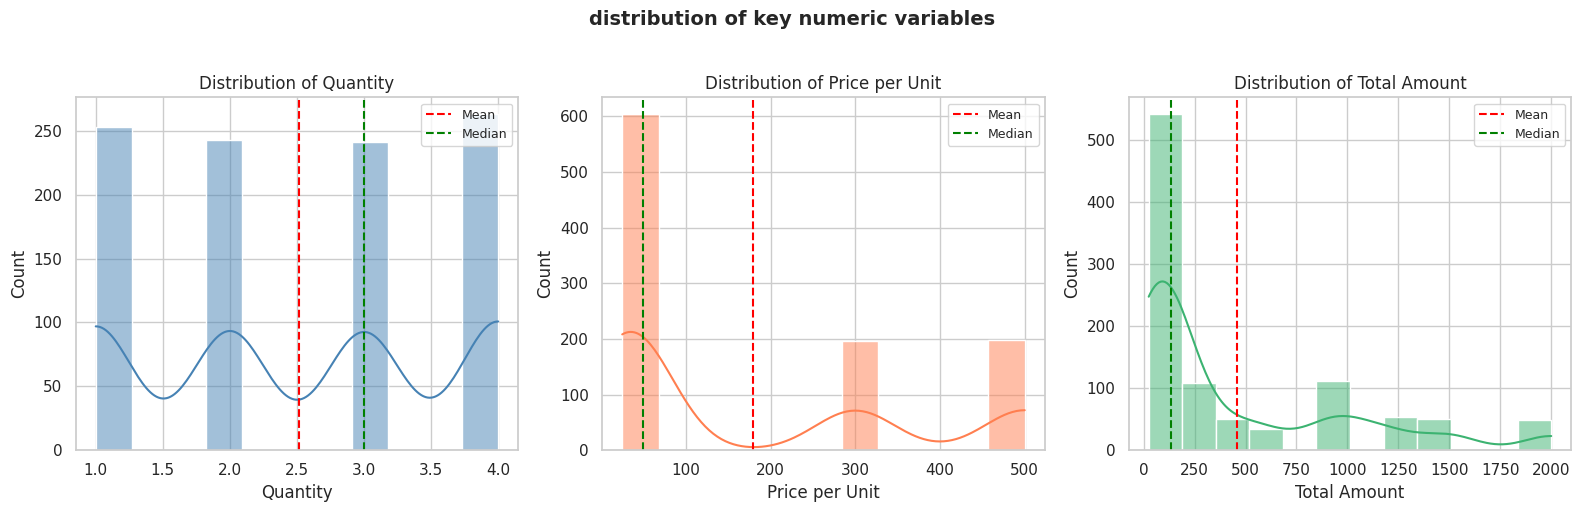

In [15]:
#--distribution plots--
fig,axes = plt.subplots(1,3,figsize=(16,5))
cols = ['Quantity','Price per Unit','Total Amount']
colors = ['steelblue','coral','mediumseagreen']

for ax,col,color in zip(axes,cols,colors):
  sns.histplot(df[col],kde=True,ax=ax,color=color)
  ax.axvline(df[col].mean(),color='red',ls='--',lw=1.5,label='Mean')
  ax.axvline(df[col].median(),color='green',ls='--',lw=1.5,label='Median')
  ax.set_title(f'Distribution of {col}')
  ax.legend(fontsize = 9)

plt.suptitle('distribution of key numeric variables',fontsize = 14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('fig_distributions.png',bbox_inches='tight',dpi=150)
plt.show()

## **Step 3: TIME SERIES ANALYSIS**

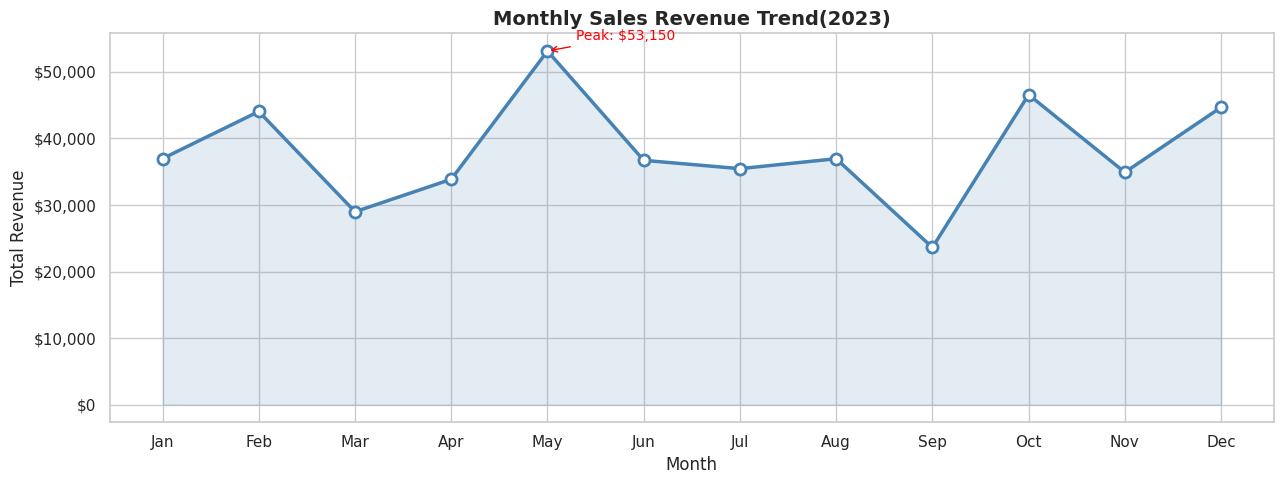

In [16]:

#----monthly sales trend-----
monthly  = df.groupby('Month')['Total Amount'].sum().reset_index()
month_names =['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['Month_name'] = monthly['Month'].apply(lambda x:month_names[x-1])

fig, ax =plt.subplots(figsize=(13,5))
ax.plot(monthly['Month'],monthly['Total Amount'],marker='o',lw=2.5,
        color='steelblue',markersize=8,markerfacecolor='white',markeredgewidth=2)
ax.fill_between(monthly['Month'],monthly['Total Amount'],alpha=0.15,color='steelblue')
ax.set_xticks(monthly['Month'])
ax.set_xticklabels(monthly['Month_name'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'${x:,.0f}'))
ax.set_title('Monthly Sales Revenue Trend(2023)',fontsize=14,fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')

#ANNOTATE PEAK
peak = monthly.loc[monthly['Total Amount'].idxmax()]
ax.annotate (f"Peak: ${peak['Total Amount']:,.0f}",
             xy=(peak['Month'],peak['Total Amount']),
             xytext = (peak['Month']+0.3,peak['Total Amount']*1.03),
             arrowprops=dict(arrowstyle='->',color='red'),color='red',fontsize=10)
plt.tight_layout()
plt.savefig('fig_monthly_trend.png',bbox_inches='tight',dpi=150)
plt.show()

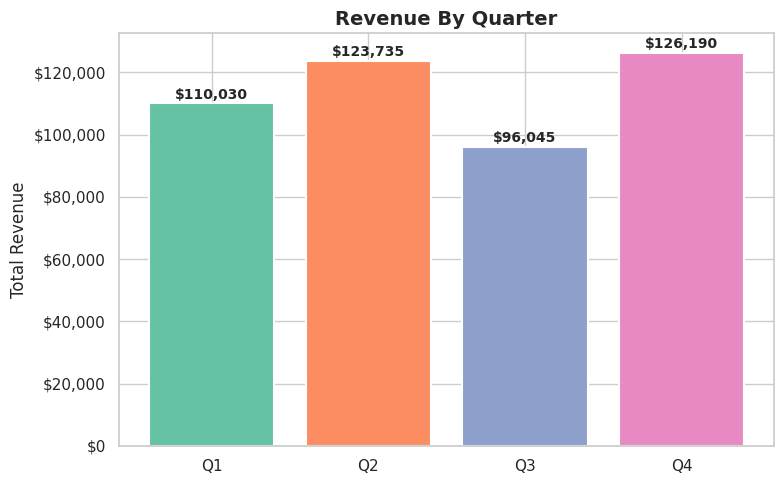

In [17]:
#Quarterly Performance
quarterly = df.groupby('Quarter')['Total Amount'].sum().reset_index()

fig,ax = plt.subplots(figsize=(8,5))
bars = ax.bar([f'Q{q}' for q in quarterly['Quarter']], quarterly['Total Amount'],
              color=sns.color_palette('Set2', 4), edgecolor='white', linewidth=1.5)

for bar in bars:
  ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+500,f'${bar.get_height():,.0f}',
          ha='center',va='bottom',fontsize=10,fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'${x:,.0f}'))
ax.set_title('Revenue By Quarter',fontsize=14,fontweight='bold')
ax.set_ylabel('Total Revenue')
plt.tight_layout()
plt.savefig('Fig_quaterly.png',bbox_inches='tight',dpi=150)
plt.show()

In [18]:
df.head(1)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Name,Day_of_week,Quarter,Age_group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,Nov,Friday,4,25-35


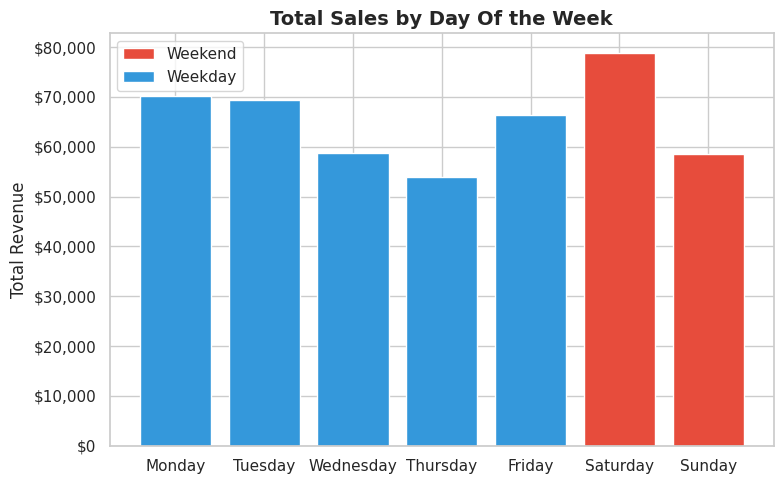

In [19]:
#Day of week Pattern

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('Day_of_week')['Total Amount'].sum().reindex(dow_order).reset_index()

fig, ax =plt.subplots(figsize=(8,5))
colors = ['#e74c3c'if d in ['Saturday','Sunday'] else '#3498db' for d in dow['Day_of_week']]
ax.bar(dow['Day_of_week'],dow['Total Amount'],color=colors,edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'${x:,.0f}'))
ax.set_title('Total Sales by Day Of the Week',fontsize=14,fontweight='bold')
ax.set_ylabel('Total Revenue')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c',edgecolor='white',label='Weekend'),
                   Patch(facecolor='#3498db',edgecolor='white',label='Weekday')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('fig_day_of_week.png',bbox_inches='tight',dpi=300)
plt.show()

# ** Step 4 customer and product analysis**

In [20]:
# ---Sales by Product Category
cat_sales = df.groupby('Product Category').agg(
    Total_Revenue=('Total Amount','sum'),
    Num_Transactions = ('Transaction ID','count'),
    Avg_Order_Value=('Total Amount','mean')
).sort_values('Total_Revenue',ascending=False).round(2)

print('==Sales by Product Category==')
cat_sales

==Sales by Product Category==


,Total_Revenue,Num_Transactions,Avg_Order_Value
Product Category,,,
Electronics,156905,342,458.79
Clothing,155580,351,443.25
Beauty,143515,307,467.48


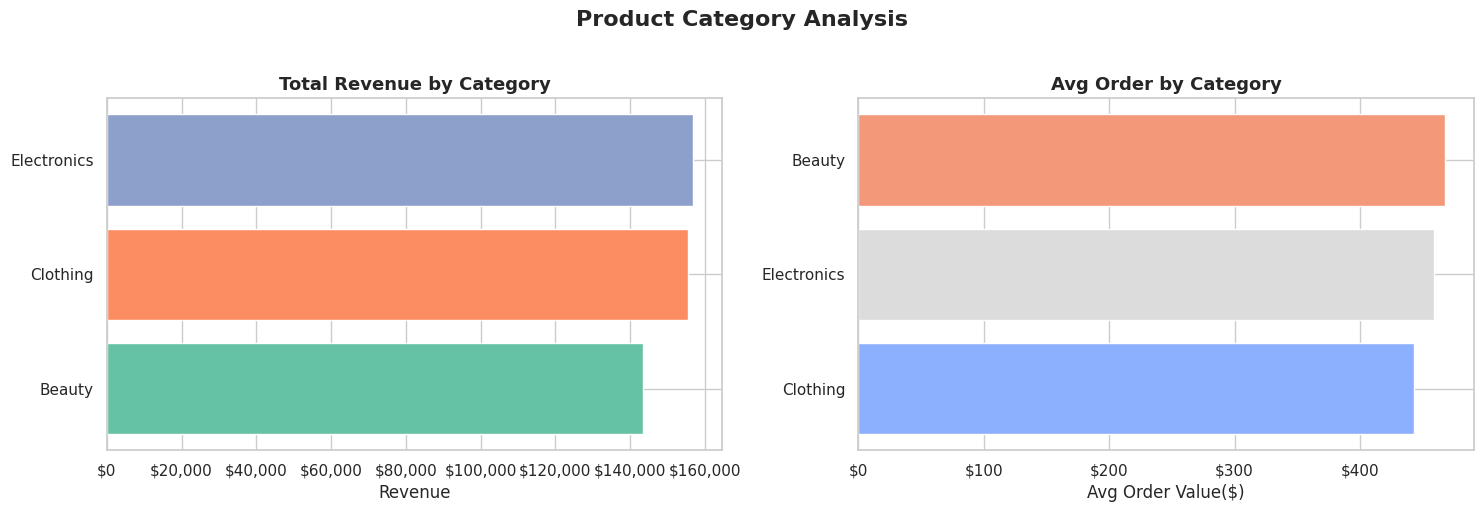

In [21]:
# -- Category By bar chart--
fig, axes =plt.subplots(1,2,figsize=(15,5))

#Revenue
cat_sorted = cat_sales.sort_values('Total_Revenue')
axes[0].barh(cat_sorted.index,cat_sorted['Total_Revenue'],
             color=sns.color_palette('Set2',len(cat_sorted)))
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'${x:,.0f}'))
axes[0].set_title('Total Revenue by Category',fontsize=13,fontweight='bold')
axes[0].set_xlabel('Revenue')

#Avg Order Value
cat_aov = cat_sales.sort_values('Avg_Order_Value')
axes[1].barh(cat_aov.index,cat_aov['Avg_Order_Value'],
             color=sns.color_palette('coolwarm',len(cat_aov)))
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'${x:,.0f}'))
axes[1].set_title('Avg Order by Category',fontsize=13,fontweight='bold')
axes[1].set_xlabel('Avg Order Value($)')

plt.suptitle('Product Category Analysis',fontsize=16,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('fig_product_category.png',bbox_inches='tight',dpi=150)
plt.show()



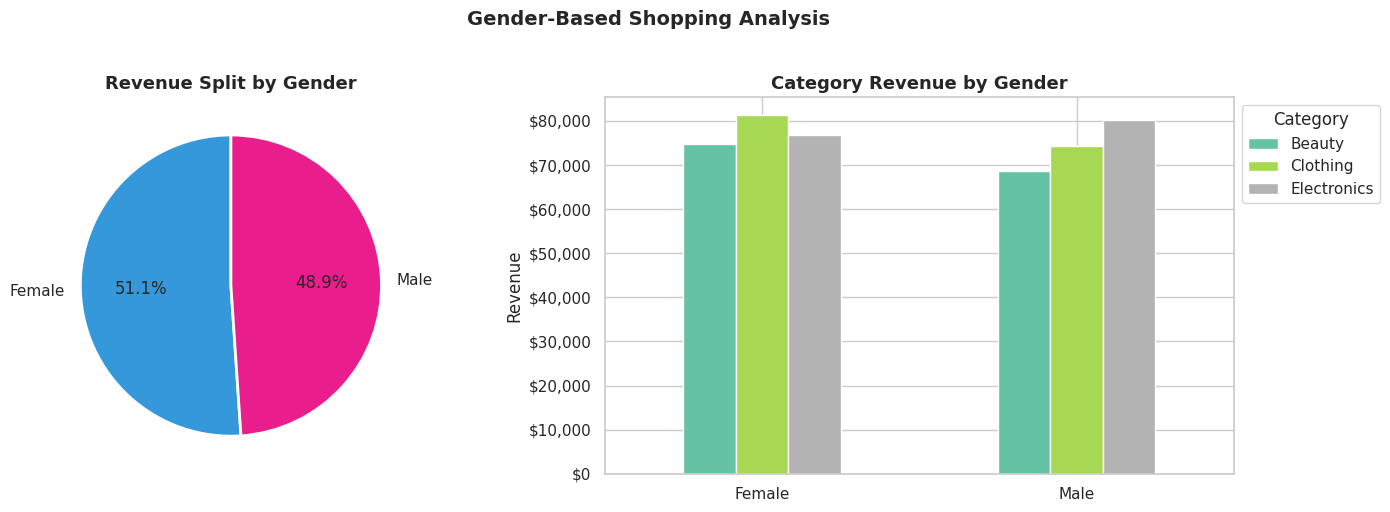

In [29]:
#--Gender Analysis------
gender_cat = df.groupby(['Gender','Product Category'])['Total Amount'].sum().unstack()

fig, axes = plt.subplots(1,2,figsize=(15,5))

#Piechart
gender_total = df.groupby('Gender')['Total Amount'].sum()
axes[0].pie(gender_total, labels=gender_total.index, autopct='%1.1f%%',
            colors=['#3498db','#e91e8c'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Revenue Split by Gender', fontsize=13, fontweight='bold')

#Grouped bar
gender_cat.plot(kind='bar',ax=axes[1],colormap='Set2',edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'${x:,.0f}'))
axes[1].set_title('Category Revenue by Gender',fontsize=13,fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x',rotation=0)
axes[1].legend(title='Category',bbox_to_anchor=(1,1))

plt.suptitle('Gender-Based Shopping Analysis',fontsize=14, fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('fig_gender_analysis.png',bbox_inches='tight',dpi=150)
plt.show()

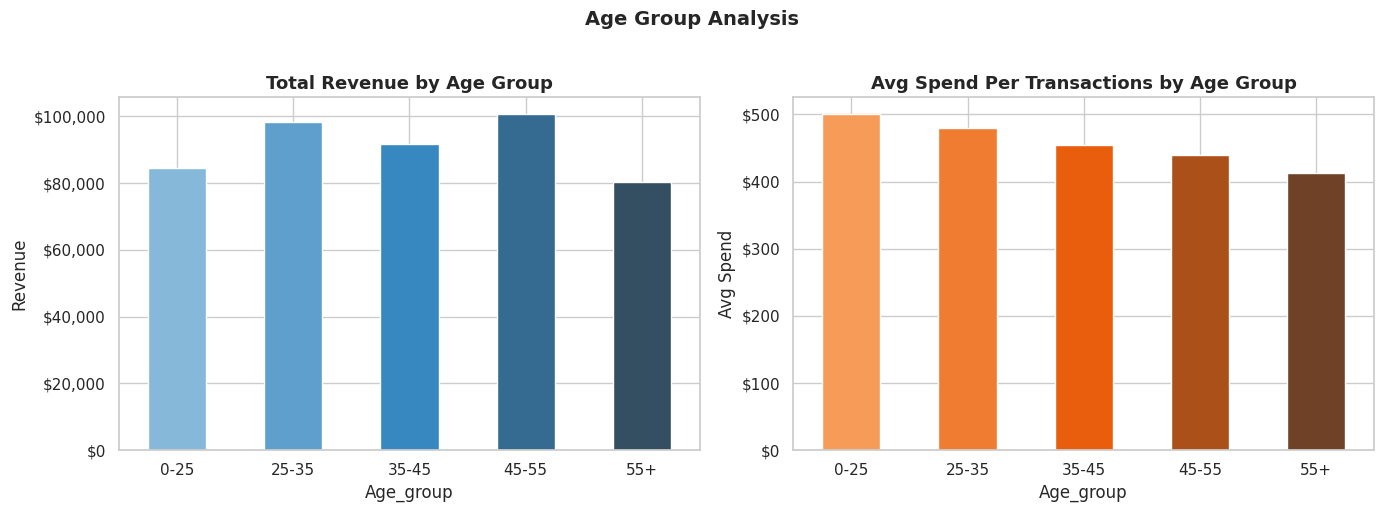

In [37]:
#--Age group Analysis
age_sales=df.groupby('Age_group',observed=True).agg(
    Total_Revenue=('Total Amount','sum'),
    Num_Customers=('Customer ID','count'),
    Avg_Spend=('Total Amount','mean')
).round(2)

fig ,axes = plt.subplots(1,2,figsize=(14,5))

age_sales['Total_Revenue'].plot(kind='bar', ax=axes[0], color=sns.color_palette('Blues_d',5),
                                 edgecolor='white')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'${x:,.0f}'))
axes[0].set_title('Total Revenue by Age Group',fontsize=13,fontweight='bold')
axes[0].tick_params(axis = 'x',rotation=0)
axes[0].set_ylabel('Revenue')

age_sales['Avg_Spend'].plot(kind='bar', ax=axes[1], color=sns.color_palette('Oranges_d',5),
                             edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'${x:,.0f}'))
axes[1].set_title('Avg Spend Per Transactions by Age Group',fontsize=13,fontweight='bold')
axes[1].tick_params(axis = 'x',rotation=0)
axes[1].set_ylabel('Avg Spend')

plt.suptitle('Age Group Analysis',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('fig_age_analysis.png',bbox_inches='tight',dpi=150)
plt.show()

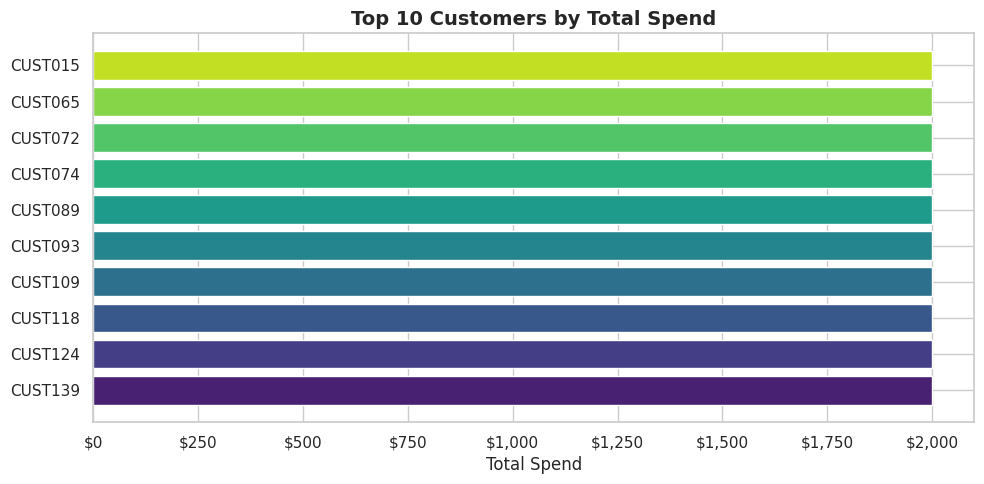

In [43]:
#TOP 10 CUSTOMERS
top_customers=df.groupby('Customer ID')['Total Amount'].sum().nlargest(10).reset_index()
top_customers.columns=['Customer ID','Total_Spend']

fig, ax =plt.subplots(figsize=(10,5))
bars = ax.barh(top_customers['Customer ID'][::-1], top_customers['Total_Spend'][::-1],
               color=sns.color_palette('viridis', 10))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'${x:,.0f}'))
ax.set_title('Top 10 Customers by Total Spend',fontsize=14,fontweight='bold')
ax.set_xlabel('Total Spend')
plt.tight_layout()
plt.savefig('fig_top_customers.png',bbox_inches='tight',dpi=150)
plt.show()


## **Step 5: Advanced Visualizations(Heatmaps and Correlation**

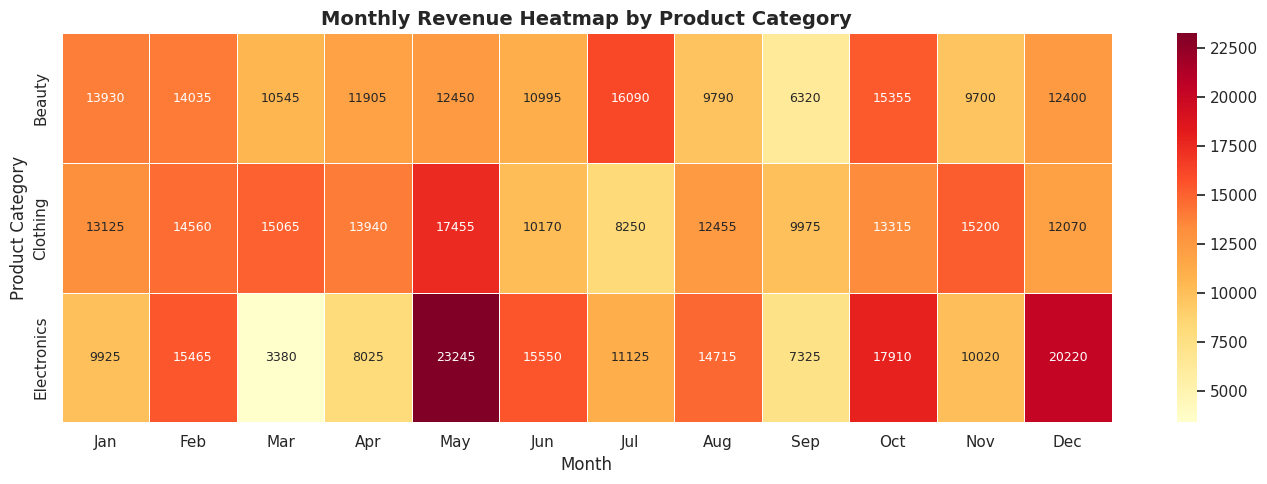

In [50]:
# ── Heatmap: Month × Category revenue ──
pivot = df.pivot_table(values='Total Amount', index='Product Category',
                       columns='Month', aggfunc='sum')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9})
ax.set_title('Monthly Revenue Heatmap by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Product Category')
plt.tight_layout()
plt.savefig('fig_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

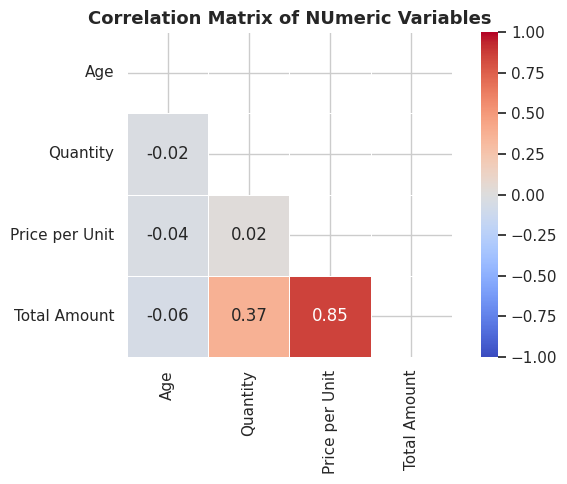

In [57]:
#-----Correlation heatmap------
corr_cols = ['Age','Quantity','Price per Unit','Total Amount']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7,5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',ax=ax,
            mask=mask,vmin=-1,vmax=1,square=True,linewidths=0.5)
ax.set_title('Correlation Matrix of NUmeric Variables',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation.png',bbox_inches='tight',dpi=150)
plt.show()


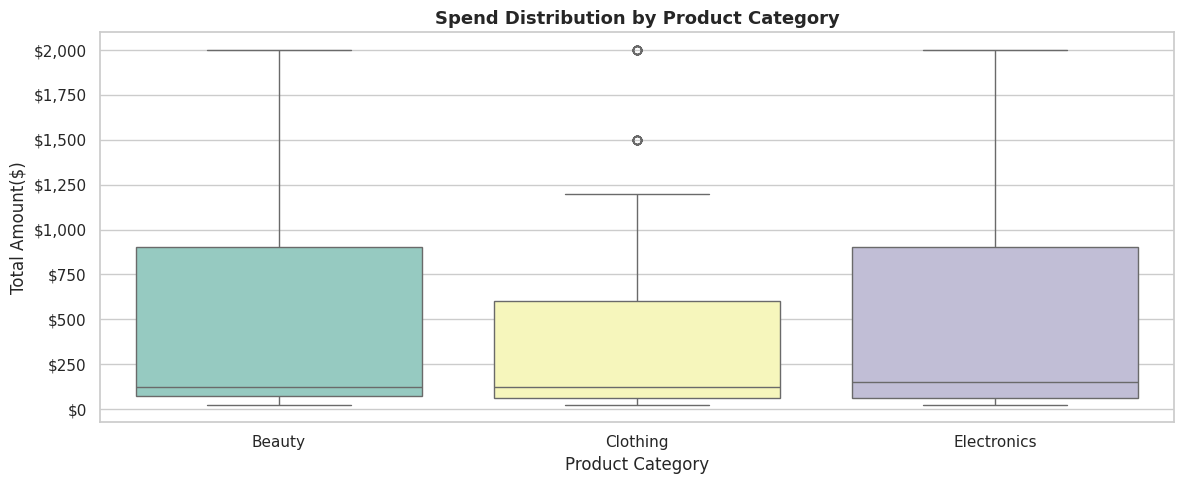

In [59]:
#---Box plots: Spend Distribution by Category----
fig, ax = plt.subplots(figsize=(12,5))
order = df.groupby('Product Category')['Total Amount'].median().sort_values().index
sns.boxplot(data=df ,x='Product Category',y='Total Amount',
            order=order,palette='Set3',ax=ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'${x:,.0f}'))
ax.set_title('Spend Distribution by Product Category',fontsize=13,fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Amount($)')
plt.tight_layout()
plt.savefig('fig_boxplot.png',bbox_inches='tight',dpi=150)
plt.show()

In [66]:
df.head(3)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Name,Day_of_week,Quarter,Age_group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,Nov,Friday,4,25-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,Feb,Monday,1,25-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,Jan,Friday,1,45-55


### **Step 6 :KEY FINDINGS AND ACTIONABLE RECOMMENDATIONS**

In [69]:
#----Summary Statistics----
print('='*55)
print('          EXECUTIVE SUMMARY')
print('='*55)
print(f"Total Transactions  : {len(df):,}")
print(f"Total Revenue       : ${df['Total Amount'].sum():,.2f}")
print(f"Avg Order Value     : ${df['Total Amount'].mean():,.2f}")
print(f"Unique Customers    : {df['Customer ID'].nunique():,}")
print(f"Date Range          : {df['Date'].min().date()} → {df['Date'].max().date()}")
print()
print('Top Category by Revenue:')
top_cat = cat_sales['Total_Revenue'].idxmax()
print(f"  → {top_cat} (${cat_sales.loc[top_cat,'Total_Revenue']:,.2f})")
print()
peak_month = monthly.loc[monthly['Total Amount'].idxmax()]
print(f"Peak Month: {peak_month['Month_name']} with ${peak_month['Total Amount']:,.2f}")
print('='*55)



          EXECUTIVE SUMMARY
Total Transactions  : 1,000
Total Revenue       : $456,000.00
Avg Order Value     : $456.00
Unique Customers    : 1,000
Date Range          : 2023-01-01 → 2024-01-01

Top Category by Revenue:
  → Electronics ($156,905.00)

Peak Month: May with $53,150.00


# **RECOMMENDATION**

Based on the EDA, the following actionable recommendations are proposed:


1.   Capitalize on Peak Months
     *   The data shows clear seasonal peaks.Increase inventory and marketing spend in high revenue months to maximize returns. Run targeted campaigns heading into those periods.

2.   Promote High-Value Categories
      *   Electronics drives the highest average order value.Create bundle offers and loyalty rewards for electronics buyers to boost repeat purchases.
3. Target the 25-45 Age Group
     *   This age group consistently shows high spending. Design Loyalty programs and personalized promotions tailored to their preferred categories.

4. Weekend vs Weekday Strategy
     * If Sales dip on weekdays,introduce weekday flash sales or exclusive mid week deals to balance traffic across the week.
5. Customer Retention for top spenders
     *   The top 10 Customers contribute dispropotionate revenue. Create a VIP tier with exclusive discounts ans early access to new products to retain them.
6. Low Perfoming Category Boost

    * Category with low average order values should be reviewed.Consider cross seelling with high performing categories or adjusting pricing strategies.













